# imported libraries

In [2]:
!pip install xgboost
!pip install imbalanced-learn
! pip install catboost

In [27]:
import pandas as pd
import xgboost as xgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score ,RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.ensemble import StackingClassifier , BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Data preprocessing

In [10]:
df_train = pd.read_csv('train.csv')
df_train.shape

(570685, 22)

In [4]:
test =pd.read_csv('test.csv')
test.shape

(104287, 22)

In [ ]:
df_train.head()

,flow_time,header_size,packet_duration,overall_rate,src_rate,dst_rate,fin_packets,urg_packets,rst_packets,max_value,...,syn_flags,rst_flags,psh_flags,ack_flags,protocol_http,protocol_https,protocol_tcp,protocol_udp,protocol_icmp,label
0,0.041268,15499.00,64.00,7805.845961,7805.845961,0.0,0.0,0.00,0.00,50.00,...,0,0,0,0,0,0,0,1,0,DDoS
1,0.018393,3702.54,64.00,6728.994198,6728.994198,0.0,0.0,0.00,0.01,54.28,...,0,0,0,0,0,0,0,1,0,DDoS
2,0.000000,182.00,64.00,38.559448,38.559448,0.0,0.0,0.00,0.00,182.00,...,0,0,0,0,0,0,0,1,0,DoS
3,0.109292,35027.55,62.72,6783.234241,6783.234241,0.0,0.0,0.03,0.11,65.11,...,0,0,0,0,0,0,0,1,0,DoS
4,0.000000,162.00,64.00,2.305494,2.305494,0.0,0.0,0.00,0.00,162.00,...,0,0,0,0,0,0,0,1,0,DoS


In [ ]:
test.head()

,Id,flow_time,header_size,packet_duration,overall_rate,src_rate,dst_rate,fin_packets,urg_packets,rst_packets,...,fin_flags,syn_flags,rst_flags,psh_flags,ack_flags,protocol_http,protocol_https,protocol_tcp,protocol_udp,protocol_icmp
0,0,0.000000,54.0,64.0,249.534700,249.534700,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0
1,1,4.466080,108.0,64.0,0.447820,0.447820,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,1,0,0
2,2,0.000000,54.0,64.0,1.295361,1.295361,0.0,0.0,1.0,1.0,...,0,0,0,1,1,0,0,1,0,0
3,3,0.000000,0.0,64.0,2.249081,2.249081,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
4,4,4.413071,108.0,64.0,0.453199,0.453199,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 938583 entries, 0 to 938582
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   flow_time         938583 non-null  float64
 1   header_size       938583 non-null  float64
 2   packet_duration   938583 non-null  float64
 3   overall_rate      938583 non-null  float64
 4   src_rate          938583 non-null  float64
 5   dst_rate          938583 non-null  float64
 6   fin_packets       938583 non-null  float64
 7   urg_packets       938583 non-null  float64
 8   rst_packets       938583 non-null  float64
 9   max_value         938583 non-null  float64
 10  value_covariance  938583 non-null  float64
 11  fin_flags         938583 non-null  int64  
 12  syn_flags         938583 non-null  int64  
 13  rst_flags         938583 non-null  int64  
 14  psh_flags         938583 non-null  int64  
 15  ack_flags         938583 non-null  int64  
 16  protocol_http     93

In [ ]:
test.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104287 entries, 0 to 104286
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Id                104287 non-null  int64  
 1   flow_time         104287 non-null  float64
 2   header_size       104287 non-null  float64
 3   packet_duration   104287 non-null  float64
 4   overall_rate      104287 non-null  float64
 5   src_rate          104287 non-null  float64
 6   dst_rate          104287 non-null  float64
 7   fin_packets       104287 non-null  float64
 8   urg_packets       104287 non-null  float64
 9   rst_packets       104287 non-null  float64
 10  max_value         104287 non-null  float64
 11  value_covariance  104287 non-null  float64
 12  fin_flags         104287 non-null  int64  
 13  syn_flags         104287 non-null  int64  
 14  rst_flags         104287 non-null  int64  
 15  psh_flags         104287 non-null  int64  
 16  ack_flags         10

In [9]:
test.drop('Id',axis=1,inplace=True) # droping ['id'] from test dataset

In [ ]:
df_train['label'].unique() # getting the unique values in the label

array(['DDoS', 'DoS', 'BenignTraffic', 'Mirai', 'Recon', 'MITM'],
      dtype=object)

In [ ]:
df_train.duplicated().sum() 
df_train.drop_duplicates(inplace=True) 
df_train.shape

(842396, 22)

In [ ]:
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['label'])

In [ ]:
X_trian = df_train.drop('label' , axis = 1)
Y_train = df_train['label'] 

In [ ]:
def detect_outliers(column):
  Q1 = column.quantile(0.25)
  Q3 = column.quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = column[(column < lower) | (column > upper)]
  return outliers


outliers = df_train.apply(detect_outliers , axis=0)
outliers

# Feature engineering

In [ ]:
df_train['fin_packet_ratio'] = df_train['fin_packets'] / (df_train['header_size'] + 1e-6)
test['fin_packet_ratio'] = test['fin_packets'] / (test['header_size'] + 1e-6)
df_train['urg_packet_ratio'] = df_train['urg_packets'] / (df_train['header_size'] + 1e-6)
test['urg_packet_ratio'] = test['urg_packets'] / (test['header_size'] + 1e-6)
df_train['e_overall_rate'] = np.log1p(df_train['overall_rate'])
df_train['e_src_rate'] = np.log1p(df_train['src_rate'])
df_train['e_dst_rate'] = np.log1p(df_train['dst_rate'])
test['e_overall_rate'] = np.log1p(test['overall_rate'])
test['e_src_rate'] = np.log1p(test['src_rate'])
test['e_dst_rate'] = np.log1p(test['dst_rate'])
df_train['flag_complexity'] = df_train['fin_flags'] + df_train['syn_flags'] + df_train['rst_flags'] + df_train['psh_flags'] + df_train['ack_flags']
test['flag_complexity'] = test['fin_flags'] + test['syn_flags'] + test['rst_flags'] + test['psh_flags'] + test['ack_flags']
df_train['ack_to_syn_ratio'] = df_train['ack_flags'] / (df_train['syn_flags'] + 1e-6)
test['ack_to_syn_ratio'] = test['ack_flags'] / (test['syn_flags'] + 1e-6)
df_train['ack_to_syn_ratio'] = df_train['ack_flags'] / (df_train['syn_flags'] + 1e-6)
test['ack_to_syn_ratio'] = test['ack_flags'] / (test['syn_flags'] + 1e-6)

In [ ]:
Robust = RobustScaler()
X_scaled = Robust.fit_transform(X_trian)
X_scaled = pd.DataFrame(X_scaled , columns = X_trian.columns)
test_scaled = Robust.transform(test)
test_scaled = pd.DataFrame(test_scaled , columns = test.columns)

In [ ]:
corr_M = df_train.corr()
corr_M 

,flow_time,header_size,packet_duration,overall_rate,src_rate,dst_rate,fin_packets,urg_packets,rst_packets,max_value,...,syn_flags,rst_flags,psh_flags,ack_flags,protocol_http,protocol_https,protocol_tcp,protocol_udp,protocol_icmp,label
flow_time,1.000000,0.011872,0.026723,-0.000506,-0.000506,-0.000006,-0.000667,0.001793,0.002536,0.003062,...,-0.001080,-0.000686,-0.000652,0.003349,-0.000462,0.004772,0.000335,0.000401,-0.000964,0.003094
header_size,0.011872,1.000000,0.203902,0.045677,0.045677,-0.000162,-0.018159,0.180034,0.266613,0.137522,...,-0.031504,-0.017584,-0.010976,0.068157,-0.008042,0.104596,-0.009256,0.034051,-0.023951,0.059832
packet_duration,0.026723,0.203902,1.000000,0.000707,0.000707,-0.000318,0.000507,0.024331,0.043033,0.032649,...,-0.011328,0.000256,0.001554,0.032092,-0.001899,0.038126,0.007235,-0.008435,0.000769,-0.005567
overall_rate,-0.000506,0.045677,0.000707,1.000000,1.000000,-0.000975,-0.145417,0.032863,0.039737,0.041316,...,-0.308451,-0.136223,-0.136953,-0.107140,-0.076205,-0.055907,-0.557074,0.791481,-0.142054,0.062773
src_rate,-0.000506,0.045677,0.000707,1.000000,1.000000,-0.000975,-0.145417,0.032863,0.039737,0.041316,...,-0.308451,-0.136223,-0.136953,-0.107140,-0.076205,-0.055907,-0.557074,0.791481,-0.142054,0.062773
dst_rate,-0.000006,-0.000162,-0.000318,-0.000975,-0.000975,1.000000,-0.000852,-0.000237,-0.000329,-0.000674,...,0.005143,-0.000807,-0.000825,-0.001009,-0.000489,-0.000259,0.002347,-0.001506,-0.001093,-0.001216
fin_packets,-0.000667,-0.018159,0.000507,-0.145417,-0.145417,-0.000852,1.000000,-0.024646,-0.035100,-0.057828,...,-0.131489,0.944298,-0.070049,-0.056776,0.073110,0.000831,0.269699,-0.173371,-0.125868,-0.086056
urg_packets,0.001793,0.180034,0.024331,0.032863,0.032863,-0.000237,-0.024646,1.000000,0.703960,0.234984,...,-0.045921,-0.025216,0.022706,0.212571,-0.005224,0.281066,0.062958,-0.042910,-0.034979,0.025589
rst_packets,0.002536,0.266613,0.043033,0.039737,0.039737,-0.000329,-0.035100,0.703960,1.000000,0.422350,...,-0.063733,-0.035241,-0.009150,0.310044,-0.009346,0.433488,0.095808,-0.063415,-0.048450,-0.056347
max_value,0.003062,0.137522,0.032649,0.041316,0.041316,-0.000674,-0.057828,0.234984,0.422350,1.000000,...,-0.126838,-0.069998,-0.054243,0.254388,-0.008713,0.350339,-0.043163,-0.063448,-0.026364,0.100210


In [ ]:
top_features = corr_M["label"].abs().sort_values(ascending=False)[1:]
top_features

,label
protocol_tcp,0.232204
protocol_icmp,0.178745
protocol_udp,0.150481
ack_flags,0.134799
fin_flags,0.128302
psh_flags,0.128180
rst_flags,0.110701
max_value,0.100210
syn_flags,0.094010
fin_packets,0.086056


In [19]:
highly_correlated = corr_M['label'].abs().sort_values(ascending = False)

In [ ]:
columns_to_leave = highly_correlated[1:21].index.to_list()
columns_to_drop = highly_correlated[22:].index.to_list()
columns_to_leave

['protocol_tcp',
 'protocol_icmp',
 'protocol_udp',
 'ack_flags',
 'fin_flags',
 'psh_flags',
 'rst_flags',
 'max_value',
 'syn_flags',
 'fin_packets',
 'protocol_https',
 'overall_rate',
 'src_rate',
 'header_size',
 'rst_packets',
 'protocol_http',
 'value_covariance',
 'urg_packets',
 'packet_duration',
 'flow_time']

In [21]:
df_train.drop(columns=columns_to_drop, inplace=True)


In [ ]:
x_train = df_train.drop('label', axis=1)
y_train = df_train['label']

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

counter = Counter(Y_train)
print('Before', counter)

smt = SMOTE()
X_train_sm, y_train_sm = smt.fit_resample(x_train, Y_train)

counter = Counter(y_train_sm)
print('After',counter)

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

print("Original class distribution:", Counter(X_scaled))

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(x_train, Y_train)

print("Resampled class distribution:", Counter(X_resampled))
#the under sampling technique reduced the accuracy significantly so we decided to use the scaled dataset without using any under sampling or over sampling technique

# vizualization

In [25]:
columns_to_plot = df_train[:10]

In [ ]:
columns_to_plot2 = df_train[11:].index.to_list()
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, column in enumerate(columns_to_plot):
    plt.scatter(df_train.index, df_train[column], color=colors[i], label=column,alpha=0.7)

<ipython-input-37-275f4a4789bf>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_train['psh_flags'].unique() , y=[0,1], palette='viridis')


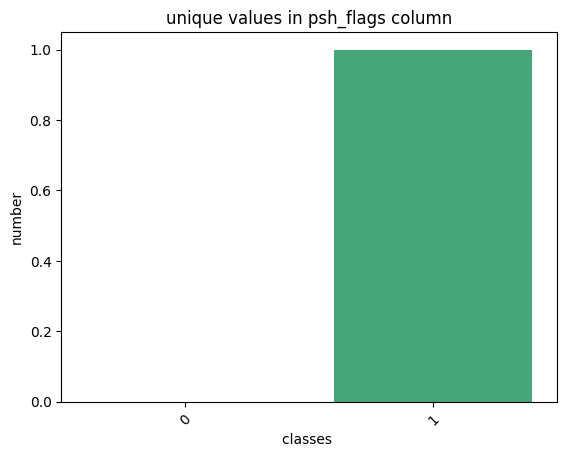

In [ ]:
df_train['psh_flags'].unique()
sns.barplot(x=df_train['psh_flags'].unique() , y=[0,1], palette='viridis')
plt.xlabel('classes ')
plt.ylabel('number')
plt.title(f'unique values in psh_flags column')
plt.xticks(rotation=45)
plt.show()

<ipython-input-23-99b335f2ee77>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_train['label'].unique() , y=[100 , 500 , 1000 , 1500 , 2000 , 25000], palette='viridis')


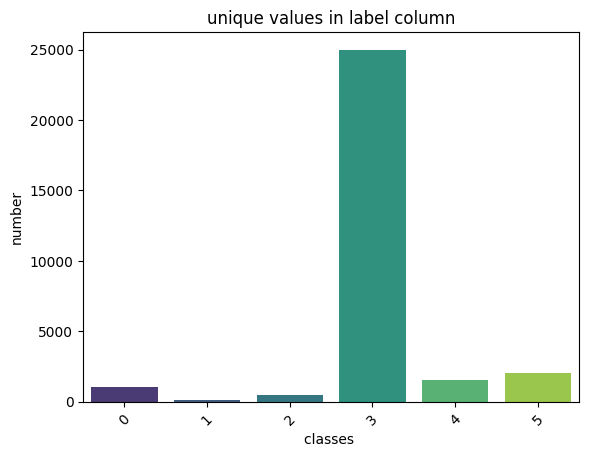

In [ ]:
df_train['label'].unique()
sns.barplot(x=df_train['label'].unique() , y=[100 , 500 , 1000 , 1500 , 2000 , 25000], palette='viridis')
plt.xlabel('classes ')
plt.ylabel('number')
plt.title(f'unique values in label column')
plt.xticks(rotation=45)
plt.show()

In [ ]:
corr_M = df_train.corr()
corr_M  # creating the correlation matrix

,flow_time,header_size,packet_duration,overall_rate,src_rate,dst_rate,fin_packets,urg_packets,rst_packets,max_value,...,ack_flags,protocol_http,protocol_https,protocol_tcp,protocol_udp,protocol_icmp,label,log_overall_rate,log_src_rate,log_dst_rate
flow_time,1.000000,0.011872,0.026723,-0.000207,-0.000207,-0.000005,-0.000667,0.001793,0.002536,0.003062,...,0.003349,-0.000462,0.004772,0.000335,0.000401,-0.000964,0.003094,-0.000506,-0.000506,-0.000006
header_size,0.011872,1.000000,0.203902,-0.003619,-0.003619,-0.000139,-0.018159,0.180034,0.266613,0.137522,...,0.068157,-0.008042,0.104596,-0.009256,0.034051,-0.023951,0.059832,0.045677,0.045677,-0.000162
packet_duration,0.026723,0.203902,1.000000,0.002290,0.002290,-0.000271,0.000507,0.024331,0.043033,0.032649,...,0.032092,-0.001899,0.038126,0.007235,-0.008435,0.000769,-0.005567,0.000707,0.000707,-0.000318
overall_rate,-0.000207,-0.003619,0.002290,1.000000,1.000000,-0.000219,-0.015912,-0.006413,-0.009568,-0.004802,...,-0.021738,-0.010250,-0.015853,-0.067409,0.085473,-0.011061,0.009002,0.247094,0.247094,-0.000256
src_rate,-0.000207,-0.003619,0.002290,1.000000,1.000000,-0.000219,-0.015912,-0.006413,-0.009568,-0.004802,...,-0.021738,-0.010250,-0.015853,-0.067409,0.085473,-0.011061,0.009002,0.247094,0.247094,-0.000256
dst_rate,-0.000005,-0.000139,-0.000271,-0.000219,-0.000219,1.000000,-0.000728,-0.000203,-0.000281,-0.000577,...,-0.000862,-0.000432,-0.000268,0.002005,-0.001286,-0.000934,-0.001039,-0.000669,-0.000669,0.997367
fin_packets,-0.000667,-0.018159,0.000507,-0.015912,-0.015912,-0.000728,1.000000,-0.024646,-0.035100,-0.057828,...,-0.056776,0.073110,0.000831,0.269699,-0.173371,-0.125868,-0.086056,-0.145417,-0.145417,-0.000852
urg_packets,0.001793,0.180034,0.024331,-0.006413,-0.006413,-0.000203,-0.024646,1.000000,0.703960,0.234984,...,0.212571,-0.005224,0.281066,0.062958,-0.042910,-0.034979,0.025589,0.032863,0.032863,-0.000237
rst_packets,0.002536,0.266613,0.043033,-0.009568,-0.009568,-0.000281,-0.035100,0.703960,1.000000,0.422350,...,0.310044,-0.009346,0.433488,0.095808,-0.063415,-0.048450,-0.056347,0.039737,0.039737,-0.000329
max_value,0.003062,0.137522,0.032649,-0.004802,-0.004802,-0.000577,-0.057828,0.234984,0.422350,1.000000,...,0.254388,-0.008713,0.350339,-0.043163,-0.063448,-0.026364,0.100210,0.041316,0.041316,-0.000674


<Axes: >

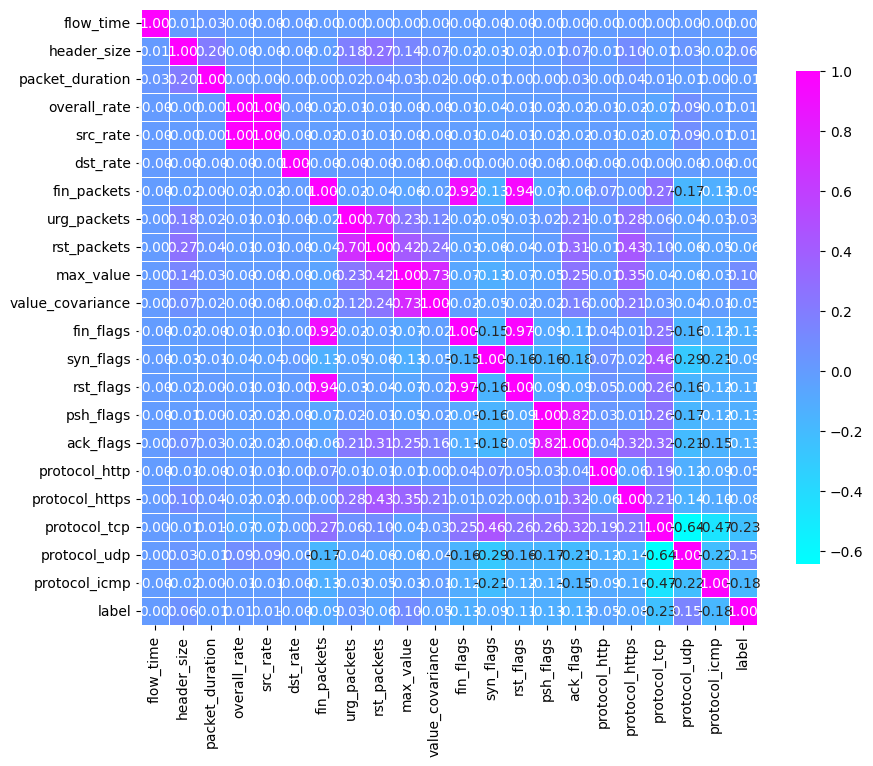

In [ ]:
plt.figure(figsize=(10, 8)) #vizualization of the correlation matrix
sns.heatmap(corr_M, annot=True, fmt='.2f', cmap='cool',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

In [ ]:
top_features = corr_M["label"].abs().sort_values(ascending=False)
top_features

,label
label,1.000000
protocol_tcp,0.232204
protocol_icmp,0.178745
protocol_udp,0.150481
ack_flags,0.134799
fin_flags,0.128302
psh_flags,0.128180
rst_flags,0.110701
max_value,0.100210
syn_flags,0.094010


<ipython-input-27-7d315452f8ab>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')


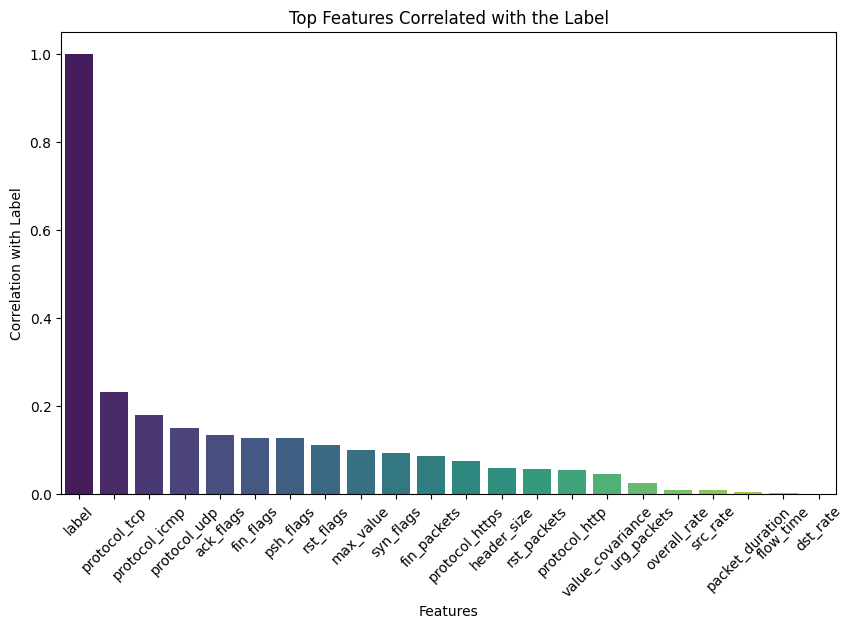

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.index, y=top_features.values, palette='viridis')
plt.xlabel('Features')
plt.ylabel('Correlation with Label')
plt.title(f'Top Features Correlated with the Label')
plt.xticks(rotation=45)
plt.show()

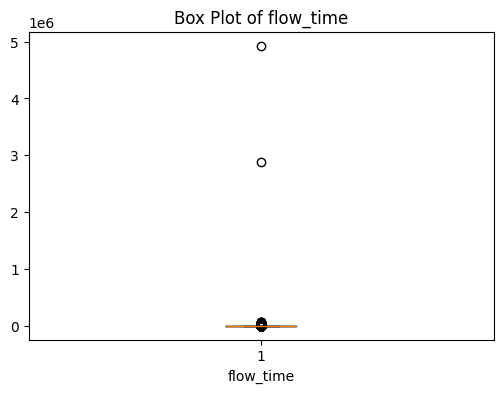

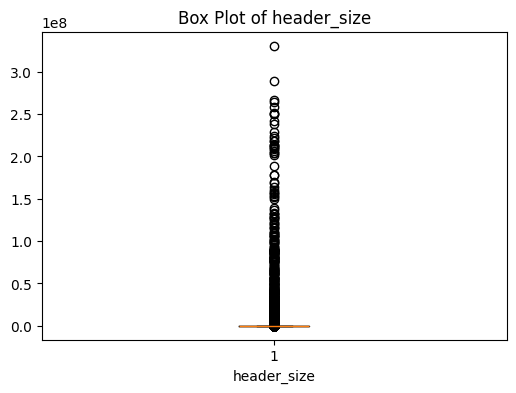

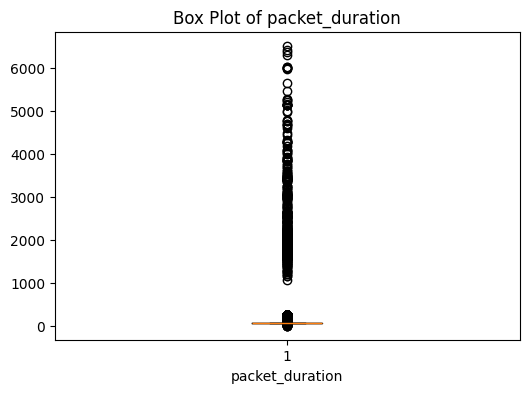

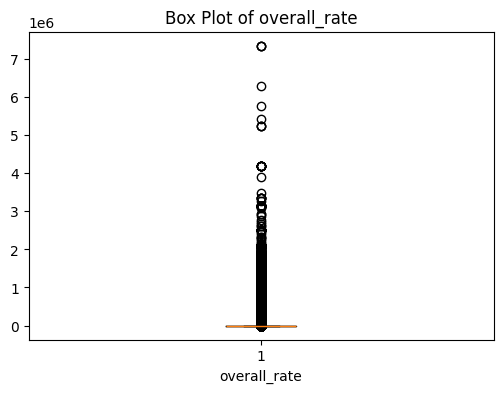

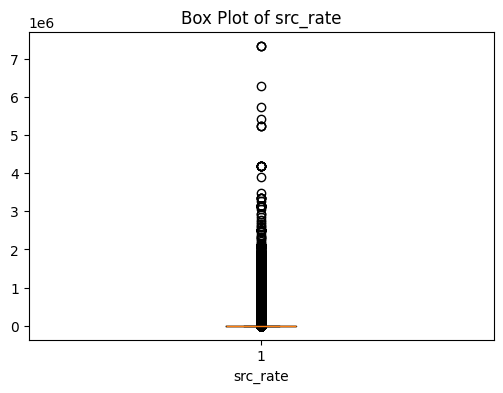

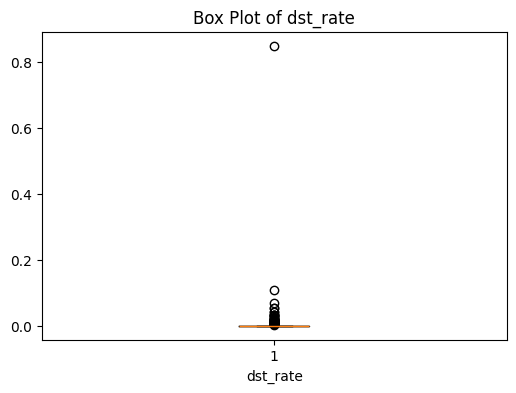

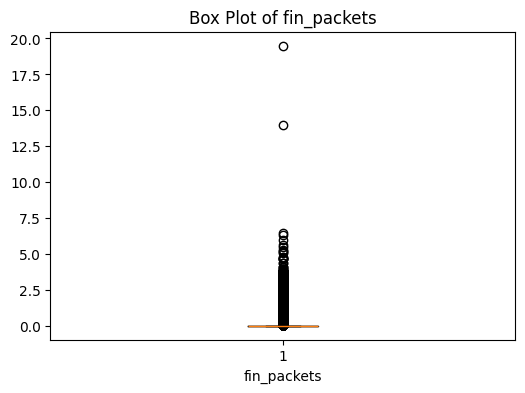

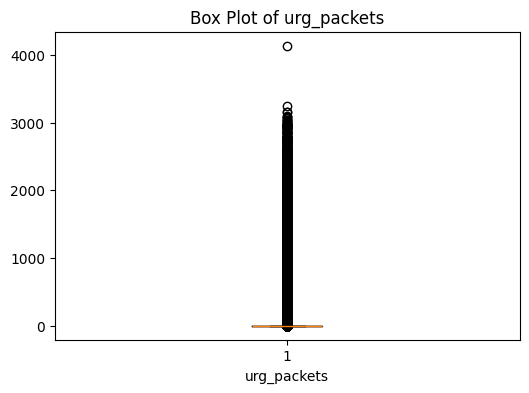

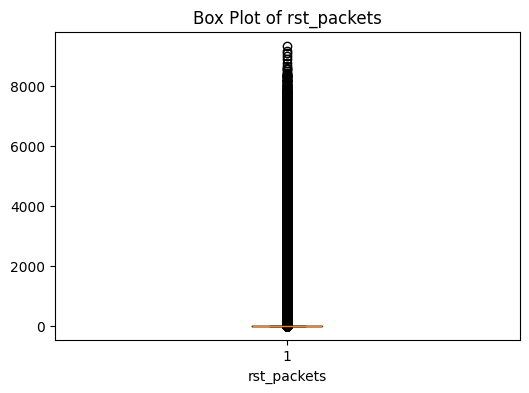

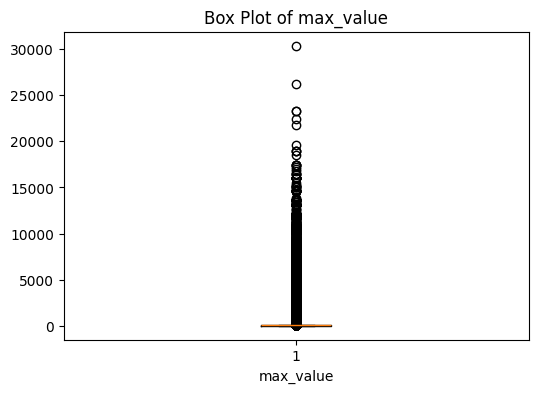

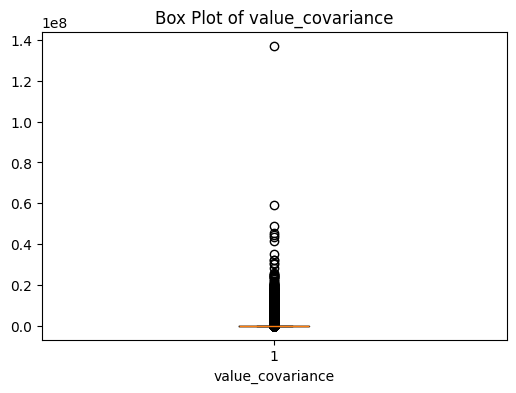

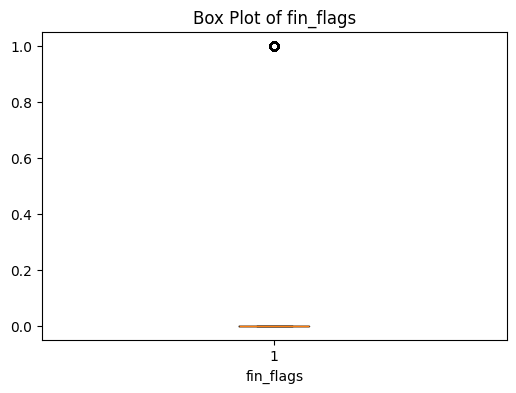

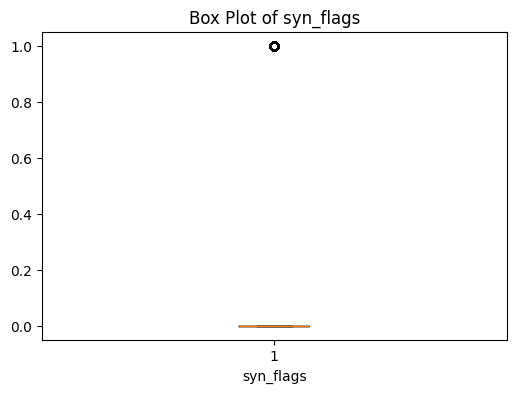

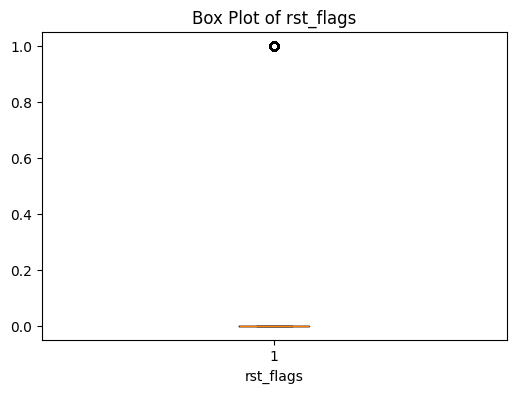

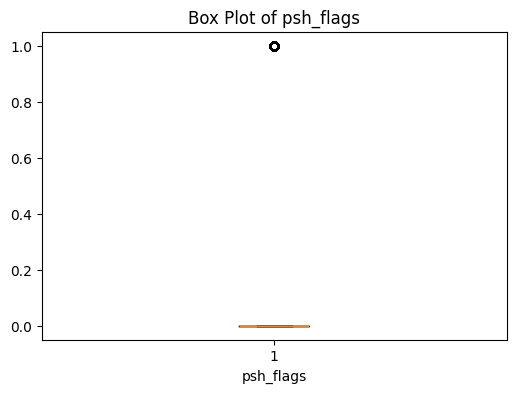

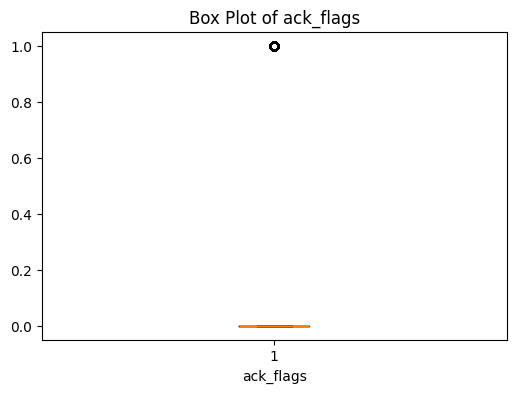

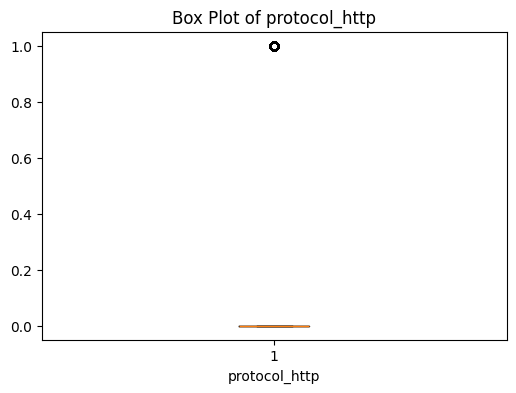

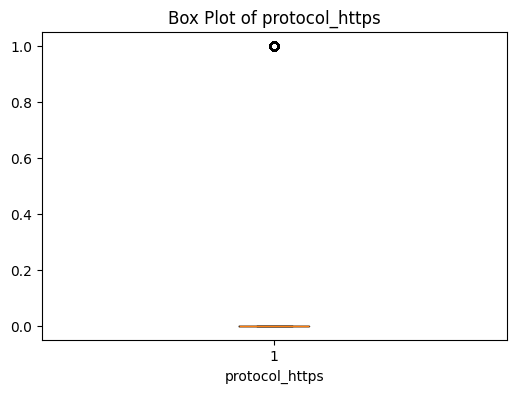

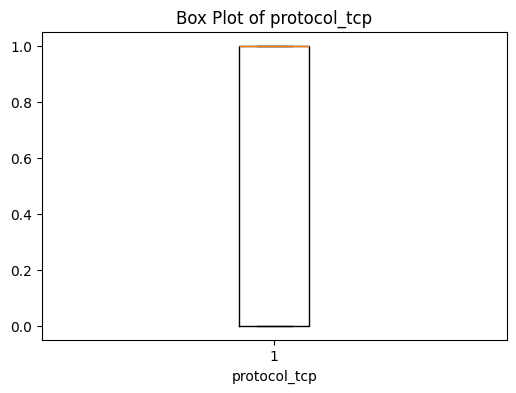

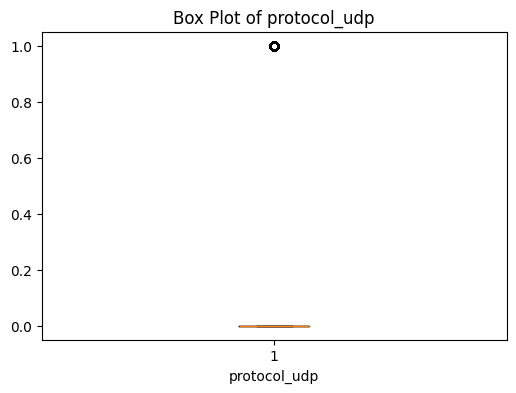

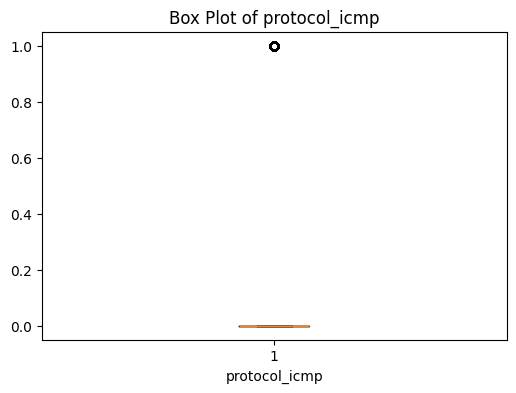

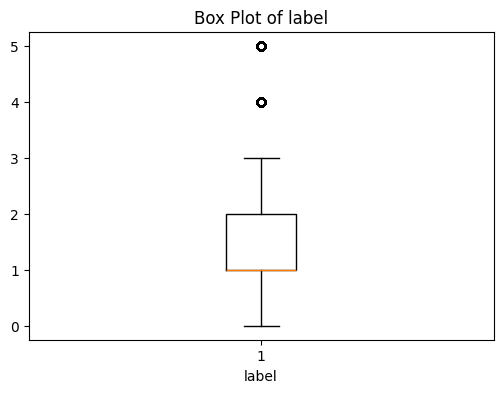

In [ ]:
for column in df_train.columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_train[column])
    plt.title(f'Box Plot of {column}')
    plt.xlabel(column)
    plt.show()

#Model training

In [ ]:
lgm=LGBMClassifier(
    objective='multiclass',
    num_class=6,
    boosting_type='gbdt',
    learning_rate=0.05,
    n_estimators=1500,
    max_depth=19,
    num_leaves=64,
    min_data_in_leaf=30,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l1=0.1,       # Lower regularization
    lambda_l2=0.1,       # Lower regularization
    scale_pos_weight=1.0,  # Adjust class weights for imbalanced classes
    min_gain_to_split=0.1,
    random_state=42
)
lgm.fit(x_train, y_train)
lgm_pred = lgm.predict(test)
#highst acc

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored

Exception ignored on calling ctypes callback function: <function _log_callback at 0x7a9f3cb32c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/basic.py", line 257, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

Exception ignored on calling ctypes callback function: <function _log_callback at 0x7a9f3cb32c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/basic.py", line 257, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Exception ignored on calling ctypes callback function: <function _log_callback at 0x7a9f3cb32c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/basic.py", line 257, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Exception ignored on calling ctypes callback function: <function _log_callback at 0x7a9f3cb32c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/lightgbm/basic.py", line 257, in _log_callback
    def _log_callback(msg: bytes) -> None:
    
KeyboardInterrupt: 


No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
model = CatBoostClassifier(loss_function='MultiClass', iterations=100, learning_rate=0.0005, depth=6)
model.fit(X_scaled, Y_train, verbose=100)
y_pred_cat = model.predict(test)

0:	learn: 1.7899974	total: 1.43s	remaining: 2m 21s
99:	learn: 1.6348898	total: 1m 11s	remaining: 0us


In [ ]:
model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=1000,               # Increased for better learning with small learning rate
    learning_rate=0.01,            # Increased from 0.0005
    depth=8,                       # Slightly deeper trees
    l2_leaf_reg=5,                 # Regularization
    bagging_temperature=1,         # For better generalization
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)
model.fit(X_scaled, Y_train, verbose=100)
y_pred_cat = model.predict(test_scaled)

0:	learn: 1.7556212	total: 2.69s	remaining: 44m 49s
100:	learn: 0.6456574	total: 2m 52s	remaining: 25m 37s
200:	learn: 0.4200037	total: 5m 40s	remaining: 22m 31s
300:	learn: 0.3404729	total: 8m 24s	remaining: 19m 32s
400:	learn: 0.3075454	total: 11m 9s	remaining: 16m 39s
500:	learn: 0.2902879	total: 13m 55s	remaining: 13m 52s
600:	learn: 0.2802276	total: 16m 40s	remaining: 11m 4s
700:	learn: 0.2727772	total: 19m 26s	remaining: 8m 17s
800:	learn: 0.2673613	total: 22m 11s	remaining: 5m 30s
900:	learn: 0.2631355	total: 24m 56s	remaining: 2m 44s
999:	learn: 0.2596346	total: 27m 39s	remaining: 0us


In [ ]:
model = MLPClassifier(hidden_layer_sizes=(81,64) ,activation='logistic',solver='adam',max_iter=1000 , random_state = 42)

model.fit(x_train,y_train)

# acc= 0.866

MLPClassifier(hidden_layer_sizes=(81, 64), max_iter=1000, random_state=42)

In [ ]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)
xgb_pred = xgb_model.predict(test)
acc = 0.91

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:26:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
xgb_model = XGBClassifier(objective='mlogloss',
    num_class=6,
    n_estimators=1500,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=5,
    reg_alpha=0.5,
    reg_lambda=1.5,
    scale_pos_weight=1,
    eval_metric='auc',
    use_label_encoder=False)
xgb_model.fit(X_trian, Y_train)
xgb_pred = xgb_model.predict(test)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:22:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [25]:
lgm=LGBMClassifier(
    objective='multiclass',
    num_class=6,
    boosting_type='gbdt',
    learning_rate=0.05,
    n_estimators=1000,
    max_depth=16,
    num_leaves=64,
    min_data_in_leaf=30,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l1=0.1,       # Lower regularization
    lambda_l2=0.1,       # Lower regularization
    scale_pos_weight=1.0,  # Adjust class weights for imbalanced classes
    min_gain_to_split=0.1,
    random_state=42
)
lgm.fit(X_trian, Y_train)
lgm_pred = lgm.predict(test)

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored

KeyboardInterrupt: 

# Ensemble

In [ ]:
train = pd.read_csv('train.csv')


# Performance Evaluation:

In [28]:
train = pd.read_csv('train.csv')
train.duplicated().sum()
train.drop_duplicates(inplace=True)
train.shape

(842396, 22)

In [ ]:
label_encoder = LabelEncoder()
df_train['label'] = label_encoder.fit_transform(df_train['label'])

In [30]:
x=df_train.drop('label',axis=1)
y=df_train['label']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#khaled
lgm=LGBMClassifier(
    objective='multiclass',
    num_class=6,
    boosting_type='gbdt',
    learning_rate=0.05,
    n_estimators=1500,
    max_depth=19,
    num_leaves=64,
    min_data_in_leaf=30,
    feature_fraction=0.9,
    bagging_fraction=0.8,
    bagging_freq=5,
    lambda_l1=0.1,       # Lower regularization
    lambda_l2=0.1,       # Lower regularization
    scale_pos_weight=1.0,  # Adjust class weights for imbalanced classes
    min_gain_to_split=0.1,
    random_state=42
)
lgm.fit(x_train, y_train)
lgm_pred = lgm.predict(x_test)
lgm_acc=accuracy_score(y_test,lgm_pred)
print(lgm_acc)
precision_lgm = precision_score(y_test, lgm_pred)
recall_lgm = recall_score(y_test, lgm_pred)
f1__lgm = f1_score(y_test, lgm_pred)
roc_auc_lgm = roc_auc_score(y_test, lgm_pred)

[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_gain_to_split is set=0.1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.1
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] lambda_l2 is set=0.1, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.1
[LightGBM] [Warning] lambda_l1 is set=0.1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=30, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=30
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored

In [ ]:
# kaggle acc = 0.913507
#nour
cat_model = CatBoostClassifier(
    loss_function='MultiClass',
    iterations=6000,                 # Early stopping overrides this
    learning_rate=0.12,             # Faster convergence
    depth=6,                        # Allow complex patterns
    l2_leaf_reg=3,                  # Reduced regularization (less underfitting)
    bootstrap_type='Bernoulli',
    subsample=0.9,                  # More row sampling diversity
    eval_metric='MultiClass',       # Track multi-class loss
    random_state=42,
    verbose=100,
    early_stopping_rounds=50,       # Stop if no improvement for 50 rounds
    task_type='CPU'                 # Remove if using GPU
)

cat_model.fit(x_train, Y_train, verbose=100)
y_cat_pred = cat_model.predict(x_test)
cat_acc=accuracy_score(y_test,y_cat_pred)
print(cat_acc)
precision_cat = precision_score(y_test, y_cat_pred)
recall_cat = recall_score(y_test, y_cat_pred)
f1__cat = f1_score(y_test, y_cat_pred)
roc_auc_cat = roc_auc_score(y_test, y_cat_pred)

In [ ]:
# jana
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(Y_train)),
    n_estimators=7000,               # Early stopping overrides this
    learning_rate=0.1,                # More stable convergence
    max_depth=8,                      # Allow deeper trees for better pattern capture
    min_child_weight=5,              # Allow smaller leaf groups
    gamma=1.5,                       # Allow more splits
    subsample=0.8,                   # Add diversity to reduce overfitting
    colsample_bytree=0.8,            # Feature sampling
    reg_alpha=1.2,                   # Balanced L1 regularization
    reg_lambda=1.2,                  # Balanced L2 regularization
    scale_pos_weight=1,              # Adjust if classes are imbalanced
    eval_metric=['mlogloss', 'merror'],  # Track both metrics
    random_state=42,
    verbosity=1,
    tree_method='hist'              # Faster training
)

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, Y_train)
xgb_pred = xgb_model.predict(x_test)
xgb_acc=accuracy_score(y_test,xgb_pred)
print(lgm_acc)
precision_xgb = precision_score(y_test, xgb_pred)
recall_xgb = recall_score(y_test, xgb_pred)
f1__xgb = f1_score(y_test, xgb_pred)
roc_auc_xgb = roc_auc_score(y_test, xgb_pred)

In [ ]:
#soha
rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=18,
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(x_train, Y_train)
preds = rf_model.predict(x_test)
rf_acc=accuracy_score(y_test,preds)
print(lgm_acc)
precision_rf = precision_score(y_test, preds)
recall_rf = recall_score(y_test, preds)
f1__rf = f1_score(y_test, preds)
roc_auc_rf = roc_auc_score(y_test, preds)

In [ ]:
class_names = label_encoder.inverse_transform(lgm_pred)

submission_df = pd.DataFrame({
    'Id': np.arange(len(class_names)),
    'Target': class_names
})

submission_df.to_csv("lgm_1_predictions.csv",index=False)

In [ ]:
f1_scores = {
    'nour': f1__cat,
    'khaled': f1__lgm,
    'jana': f1__xgb,
    'soha': f1__rf,
}

plt.figure(figsize=(5, 6))
bars = plt.bar(f1_scores.keys(), f1_scores.values(), color='purple')
plt.xticks(rotation=45)
plt.title('Model F1 Scores')
plt.ylabel('F1 Score')
plt.ylim(0.90, 1)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
roc_aucs = {
    'jana': roc_auc_xgb,
    'nour': roc_auc_cat,
    'soha ': roc_auc_rf,
    'khaled': roc_auc_lgm,
}

plt.figure(figsize=(5, 6))
bars = plt.bar(roc_aucs.keys(), roc_aucs.values(), color='green')
plt.xticks(rotation=45)
plt.title('Model ROC AUC Scores')
plt.ylabel('ROC AUC')
plt.ylim(0.7, 1)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
Recalls = {
    'khaled': recall_lgm,
    'nour': recall_cat,
    'soha': recall_rf,
    'jana': recall_xgb,
}

plt.figure(figsize=(5, 6))
bars = plt.bar(Recalls.keys(), Recalls.values(), color='red')
plt.xticks(rotation=45)
plt.title('Model Recalls')
plt.ylabel('Recall')
plt.ylim(0.90, 1)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
precisions = {
    'khaled': precision_lgm,
    'nour': precision_cat,
    'soha': precision_rf,
    'jana': precision_xgb,
}
plt.figure(figsize=(5, 6))
plt.bar(precisions.keys(), precisions.values(), color='green')
plt.xticks(rotation=45)
plt.title('Model Precisions')
plt.ylabel('Precision')
plt.ylim(0.90, 1)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
for i in range(6):
    RocCurveDisplay.from_predictions(
        y_test[:, i], lgm.predict_proba(x_test)[:, i], name=f"Class {i}"
    )
plt.plot([0, 1,2,3,4,5], [0, 1,2,3,4,5], 'k--')
plt.title("ROC Curve - Multi-Class")
plt.grid(True)
plt.show()